For this task, ill be attempting to implement basic arithmetic circuits through qiskit.
A sum of a and b can be simplified into a XOR b
its carry can be placed into a AND B

# Half-Adder

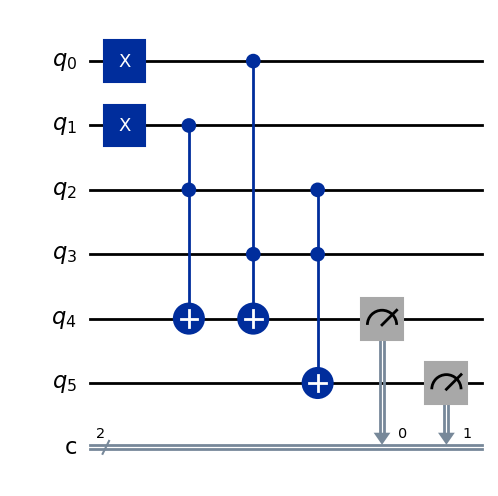

In [ ]:
from qiskit import QuantumCircuit
# from qiskit.primitives import StatevectorSampler
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import CCXGate, XGate, HGate
from qiskit.primitives import StatevectorSampler


sampler = StatevectorSampler()
#qiskit initializes qbits to |0>
#x gates flip the qbit, so its good for making them |1> states
#qubits 0 and 1 are the so called aneary(?) qbits, as in, they don't change
qr = QuantumRegister(6,"q")
cr = ClassicalRegister(2,"c")

qc = QuantumCircuit(qr, cr, name='adder circuit')
#q2 and q3 should my opperands

#add randomness to inputs
qc.append(HGate(), [2])
qc.append(HGate(), [3])

#intiate control bits
qc.append(XGate(), [0])
qc.append(XGate(), [1])
# qc.append(CCXGate(), [0,1,2])
# qc.append(CCXGate(), [0,1,3])

#XOR (sum):

qc.append(CCXGate(), [1,2,4])
qc.append(CCXGate(), [0,3,4])


#AND (Carry11):
qc.append(CCXGate(), [2,3,5])

#make sure its all reversable

# qc.append(CCXGate(), [1,2,4])

# qc.append(CCXGate(), [0,1,3])
# qc.append(CCXGate(), [0,1,2])



#this represent an AND gate, where q2 is flipped if q0 and q1 are 1 (which they are)
#q5 should hold my result
#xor opperation for the carry: q4 contains 
# qc.append(CCXGate(), [1,2,3])
qc.measure(4,0)
#carry
qc.measure(5,1)
#          ^ indicates what qubit is being meassured
#            ^ indicates in what classical register is the meassurement being depoosited in

qc.draw("mpl")

To specify what values we are going to add, we are going to have to flip them. For example: For 0 + 1, we would have to flip q3 with an xgate. Perhaps this can be achived with an if statement and function arguments. 

In [14]:

# qc.measure_all()
result = sampler.run([qc], shots=1024).result()
print(result[0].data)
# print(dir(result[0].data.c6.get_counts()))

DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>))


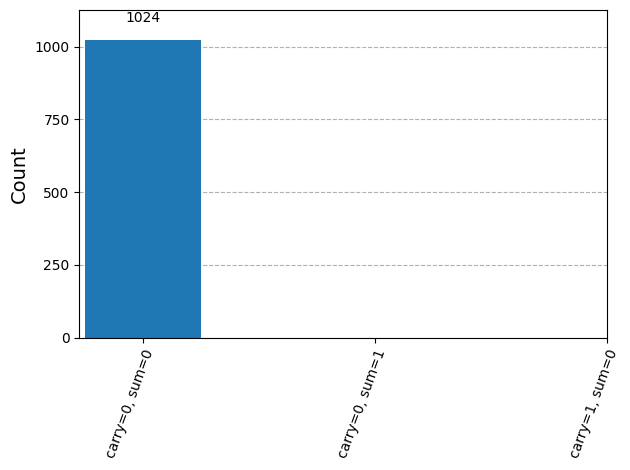

In [15]:
counts = result[0].data.c.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    # "carry=1, sum=1": counts.get("11", 0),
}

plot_histogram(pretty_counts)

The above histogram represents the distribution found in the half-adder's truth table

00: 1/4

01: 1/2

10: 1/4


# One bit Full-Adder

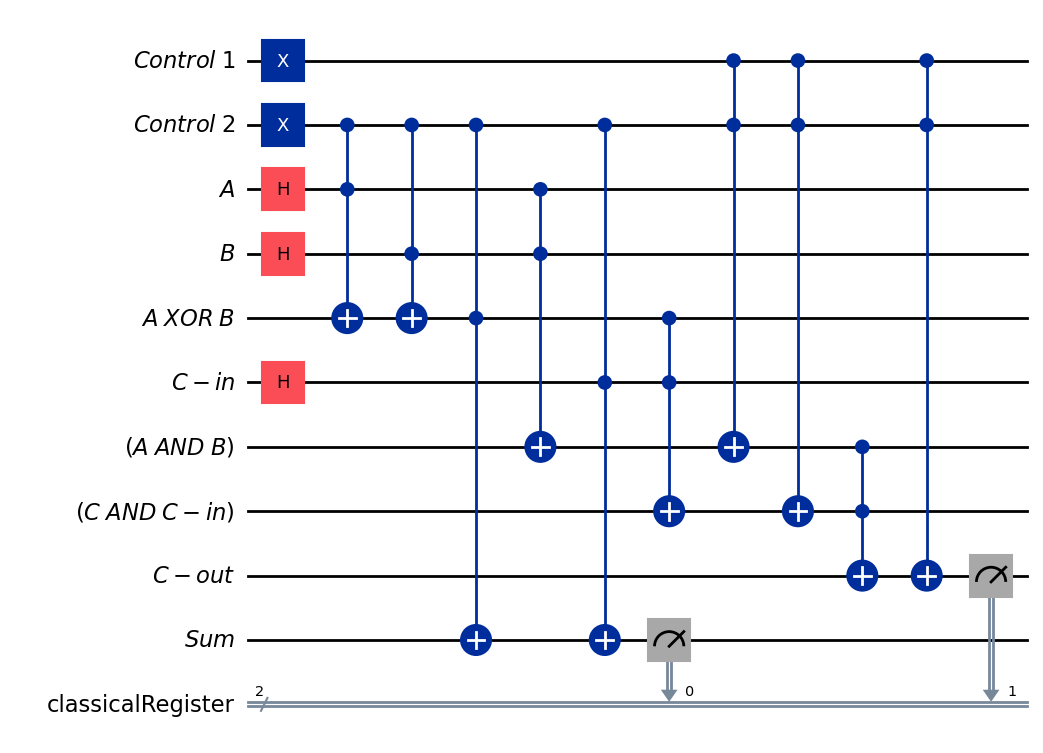

In [4]:
def oneBitFullAdder(number1 = None, number2 = None):
    from qiskit import QuantumCircuit
    # from qiskit.primitives import StatevectorSampler
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display





        

    # sampler = StatevectorSampler()
    #qiskit initializes qbits to |0>
    #x gates flip the qbit, so its good for making them |1> states
    #qubits 0 and 1 are the so called aneary(?) qbits, as in, they don't change
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    qr2 = QuantumRegister(1,"A")
    qr3 = QuantumRegister(1,"B")
    qr4 = QuantumRegister(1,"A XOR B")
    qr5 = QuantumRegister(1,"C-in")
    qr6 = QuantumRegister(1,"(A AND B)")
    qr7 = QuantumRegister(1,"(C AND C-in)")
    qr8 = QuantumRegister(1,"C-out")
    qr9 = QuantumRegister(1,"Sum")


    cr = ClassicalRegister(2,"classicalRegister")

    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, cr, name='Full-adder circuit')

    #add randomness


    #order:
    Control1 = 0
    Control2 = 1
    A = 2
    B = 3
    C = 4
    C_in = 5
    aANDb = 6
    cANDc_in = 7
    C_out = 8
    SUM = 9

    if(number1 is None and number2 is None):
        qc.append(HGate(), [A])
        qc.append(HGate(), [B])
        qc.append(HGate(), [C_in])
    else:
        if(number1 > 1 or number1 < 0 or number2 > 1 or number2 < 0):
            print("Numbers to be added must both be either 1 or 0")
            return None
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        if(binary1 == "1"):
            qc.append(XGate(), [A])
        if(binary2 == "1"):
            qc.append(XGate(), [B])



    #set the control bit to |1>
    qc.append(XGate(), [Control1])
    qc.append(XGate(), [Control2])

    #set up the SUM
    #First XOR (sum):
    #XOR A and B to fill C
    qc.append(CCXGate(), [Control2,A,C])
    qc.append(CCXGate(), [Control2,B,C])

    #Perform XOR between C and C-in to get the sum
    qc.append(CCXGate(), [Control2,C,SUM])
    qc.append(CCXGate(), [Control2,C_in,SUM])

    #Sum is done

    #C-OUT

    #First, AND between A and B
    qc.append(CCXGate(),[A,B,aANDb])

    #Then, AND between C and C-IN
    qc.append(CCXGate(),[C,C_in,cANDc_in])


    #Finally, OR both of the opperated qbits
    #Invert both
    # NOT(A and B)
    qc.append(CCXGate(),[Control1,Control2,aANDb])
    # NOT(C and C-in)
    qc.append(CCXGate(),[Control1,Control2,cANDc_in])

    #Apply DEmorgan (AND (NOT(A and B) and (NOT(C and C-in)) and get the C-Out

    qc.append(CCXGate(),[aANDb,cANDc_in,C_out])

    #Apply the final inversion of de morgan:

    qc.append(CCXGate(),[Control1,Control2,C_out])


    # #Reverse the opperation due to entanglement:
    # qc.append(CCXGate(), [1,3,4])
    # qc.append(CCXGate(), [1,2,4])







    #this represent an AND gate, where q2 is flipped if q0 and q1 are 1 (which they are)
    #q5 should hold my result

    #xor opperation for the carry: q4 contains 
    #get the SUM first
    qc.measure(SUM,0)
    # Then the carry-out
    qc.measure(C_out,1)


    display(qc.draw("mpl"))
    return qc
qc = oneBitFullAdder()

# Optimization

In [5]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_kingston"
service = QiskitRuntimeService()
backend = service.backend(backend_name)

qc_transpiled = transpile(qc, backend=backend, optimization_level=0)
print("Transpiled and got the backend")


Transpiled and got the backend


# Execute on hardware

In [6]:
from qiskit_ibm_runtime import Sampler


sampler = Sampler(mode=backend)

job = sampler.run([qc_transpiled])

print(f"job_id: {job.job_id()}")

print(f"job status: {job.status()}")
print(type(job.status()))




job_id: d81pjjvoha1c73bkn510
job status: QUEUED
<class 'str'>


['ERROR', 'JOB_FINAL_STATES', '__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_api_client', '_backend', '_creation_date', '_empty_result_queue', '_error_message', '_error_msg_from_job_response', '_executor', '_final_result_decoder', '_image', '_job_id', '_private', '_program_id', '_queue_info', '_reason', '_reason_code', '_service', '_session_id', '_set_error_message', '_set_status', '_set_status_and_error_message', '_status', '_status_from_job_response', '_tags', '_usage_estimation', '_version', 'backend', 'cancel', 'cancelled', 'creation_date', 'done', 'error_message', 'errored', 'image', 'in_final_state', 'inputs', 'instance', 'job_id', 'logs', 'metadata', 'metrics', 'primitive_id', 'private', 'properties', 'result', 'running', 'session_id', 'status', 'tags', 'update_tags', 'usage', 'usage_estimation', 'wait_for_final_state']


In [7]:
print(f"job status: {job.status()}")
print(type(job.status()))


job status: QUEUED
<class 'str'>


In [8]:
print(job.job_id())

d81pjjvoha1c73bkn510


# Hardware

DataBin(classicalRegister=BitArray(<shape=(), num_shots=4096, num_bits=2>)) 



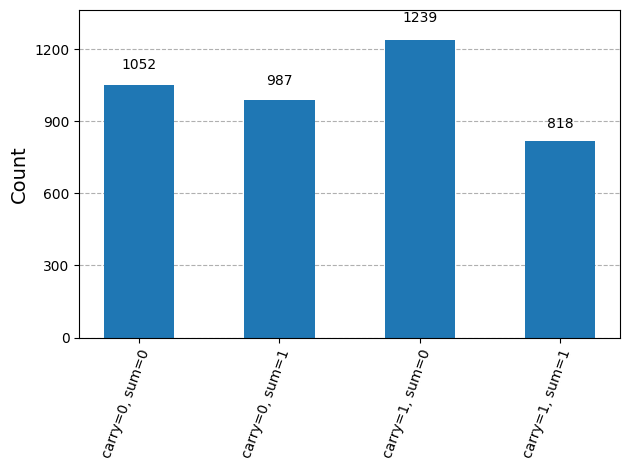

In [10]:
result = job.result()
print(result[0].data, "\n")
Real_counts = result[0].data.classicalRegister.get_counts()
pretty_counts = {
    "carry=0, sum=0": Real_counts.get("00", 0),
    "carry=0, sum=1": Real_counts.get("01", 0),
    "carry=1, sum=0": Real_counts.get("10", 0),
    "carry=1, sum=1": Real_counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}

display(plot_histogram(pretty_counts))

In [11]:
dir(job)
print(job.metrics())

{'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.45.0,qiskit-2.3.0*,qiskit_aer-0.17.2', 'timestamps': {'created': '2026-05-12T21:21:19.583011Z', 'finished': '2026-05-12T21:21:25.279783Z', 'running': '2026-05-12T21:21:20.630096Z'}, 'bss': {'seconds': 2}, 'usage': {'quantum_seconds': 2, 'seconds': 2, 'status': 'complete'}}


# Simulation

DataBin(classicalRegister=BitArray(<shape=(), num_shots=4096, num_bits=2>)) 



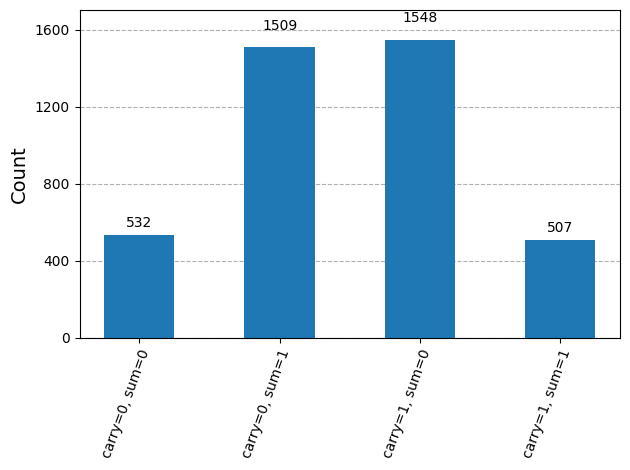

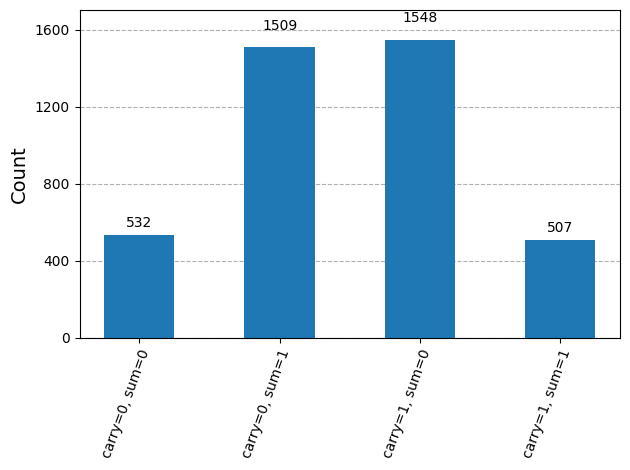

In [12]:
from qiskit.primitives import StatevectorSampler
from IPython.display import display
from qiskit.visualization import plot_histogram



samplerSim = StatevectorSampler()

result = samplerSim.run([qc], shots=(1024*4)).result()
print(result[0].data, "\n")
counts = result[0].data.classicalRegister.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    "carry=1, sum=1": counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}

display(plot_histogram(pretty_counts), plot_histogram(pretty_counts))

The above histogram represents the distribution found in the full adder's truth table

00: 1/8

10: 3/8

01: 3/8

11: 1/8

# Metrics:
## Simulated Circuit depth vs transpiled circuit's depth

In [13]:
#
print(f"og circuit's depth: {qc.depth()}")
print(f"transpiled circuit's depth: {qc_transpiled.depth()}")

og circuit's depth: 10
transpiled circuit's depth: 568


#  Error rate

In [ ]:
print("Percent error for Carry = 0 and Sum = 0")
num = (abs((counts["00"] - Real_counts["00"] ) / Real_counts["00"])) * 100
print(f"{round(num,2)}%\n")

print("Percent error for Carry = 0 and Sum = 1")
num = (abs((counts["01"] - Real_counts["01"] ) / Real_counts["01"])) * 100
print(f"{round(num,2)}%\n")

print("Percent error for Carry = 1 and Sum = 0")
num = (abs((counts["10"] - Real_counts["10"] ) / Real_counts["10"])) * 100
print(f"{round(num,2)}%\n")

print("Percent error for Carry = 1 and Sum = 1")
num = (abs((counts["11"] - Real_counts["11"] ) / Real_counts["11"])) * 100
print(f"{round(num,2)}%\n")

Percent error for Carry = 0 and Sum = 0
79.5%

Percent error for Carry = 0 and Sum = 1
301.07%

Percent error for Carry = 1 and Sum = 0
50.53%

Percent error for Carry = 1 and Sum = 1
138.29%



# T-depth

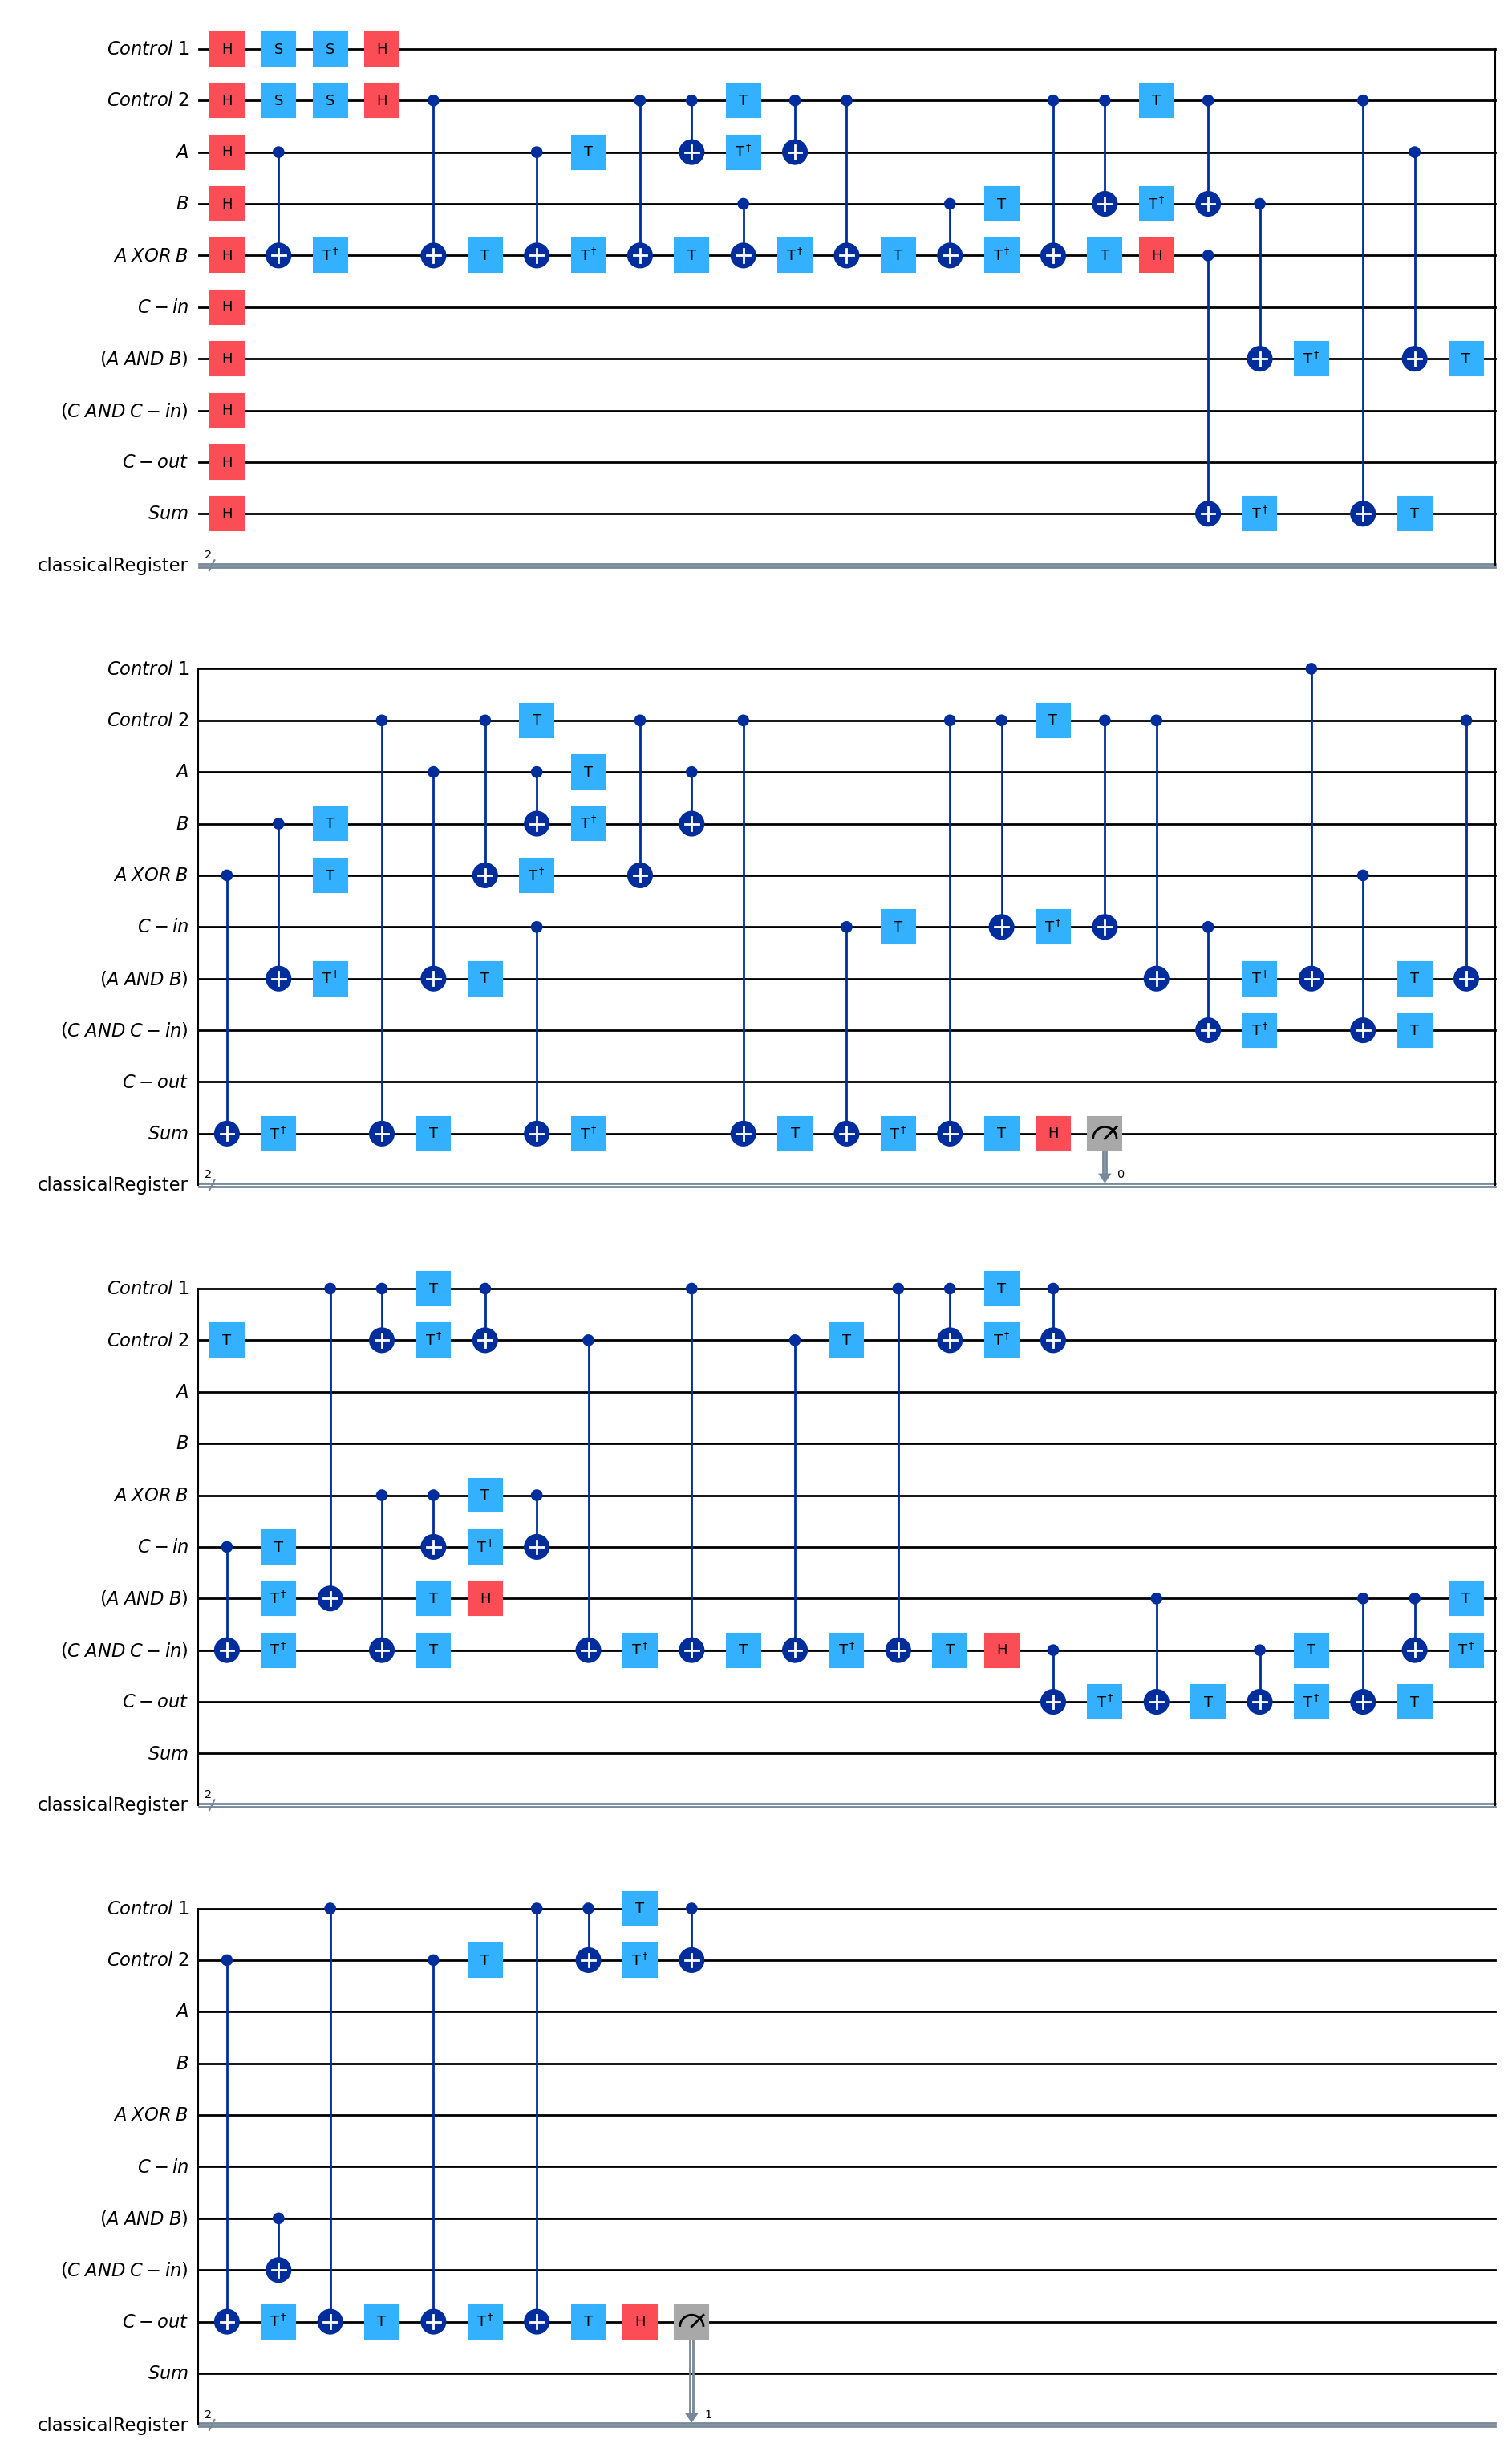

In [ ]:
from qiskit import transpile

decomposed = transpile(qc, basis_gates=['cx', 'h', 't', 'tdg', 's', 'sdg'])
    
decomposed.draw("mpl")


In [ ]:
print(decomposed.count_ops())

OrderedDict({'cx': 60, 't': 40, 'tdg': 30, 'h': 17, 's': 4, 'measure': 2})


In [ ]:
from qiskit.converters import circuit_to_dag

dag = circuit_to_dag(decomposed)

t_depth = 0
for layer in dag.layers():
    if any(node.name in ['t', 'tdg'] for node in layer['graph'].op_nodes()):
        t_depth += 1

print("T-depth:", t_depth)

T-depth: 43


Python(70509) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


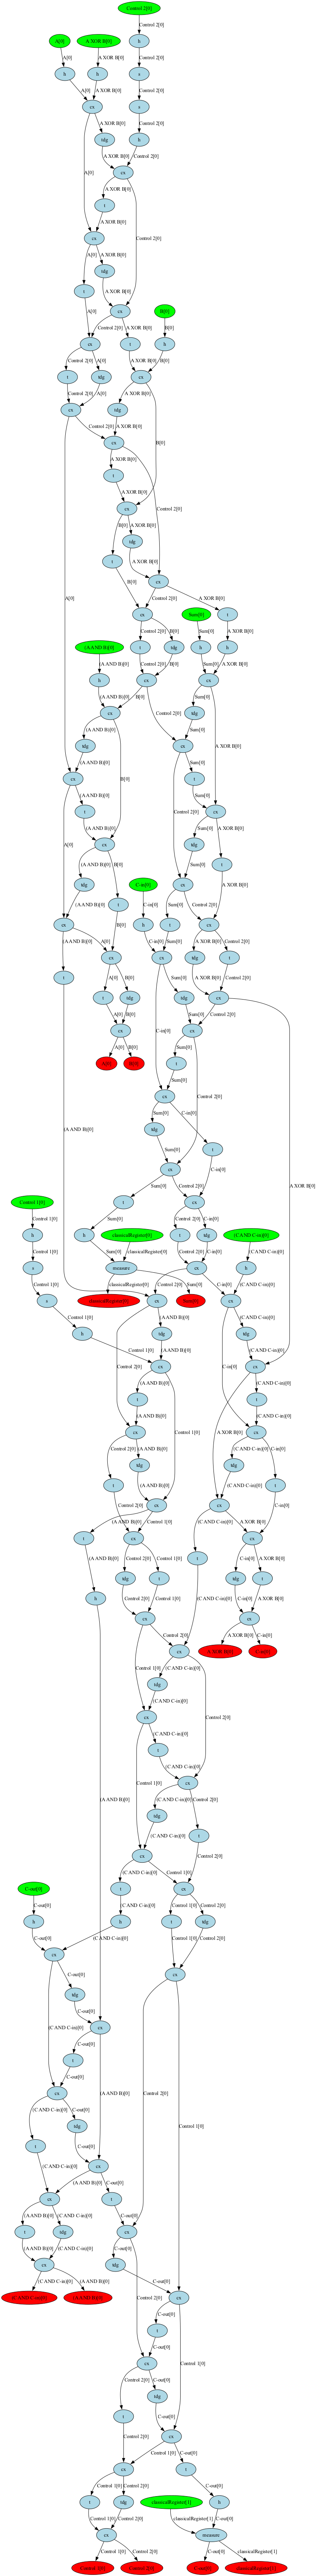

In [ ]:
dag.draw()

# Testing survival of inputed operations
## If i were to give the circuit "0 + 0", then all the results should point to the bitstring "00" as sum is 0 and carry is 0:

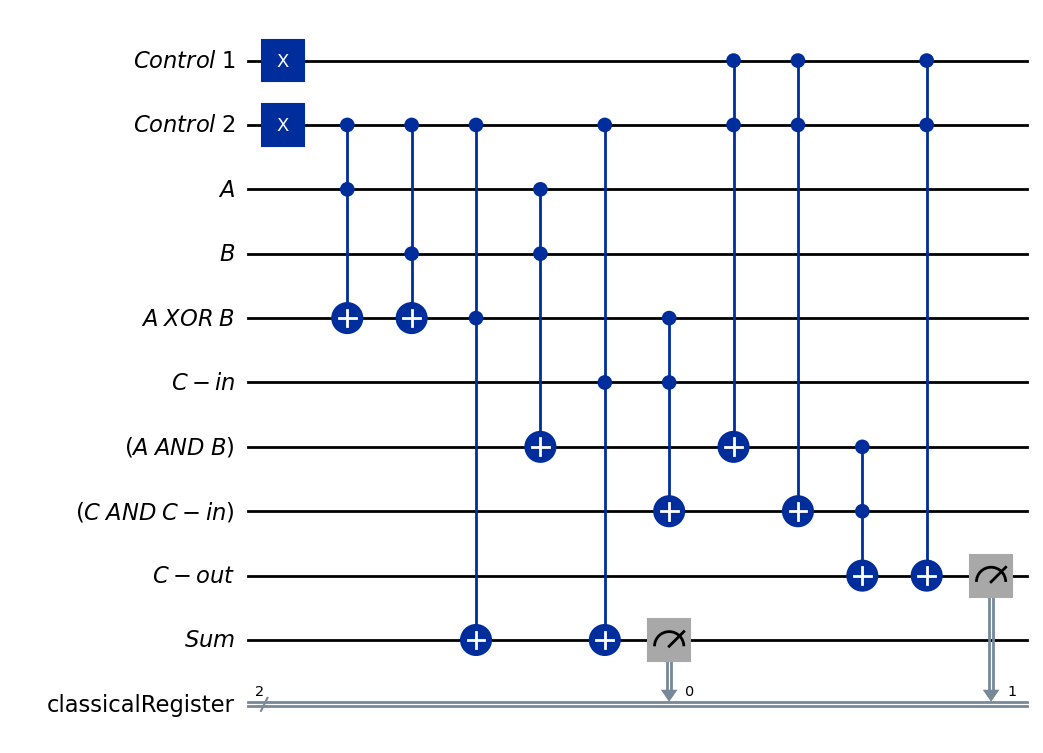

DataBin(classicalRegister=BitArray(<shape=(), num_shots=4096, num_bits=2>)) 



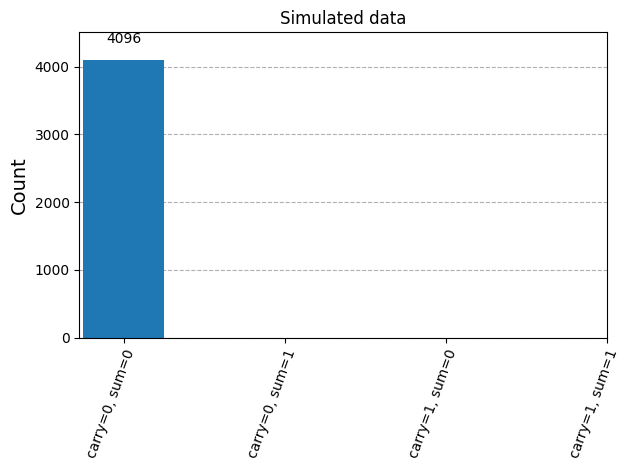

In [17]:
qc = oneBitFullAdder(0,0)
samplerSim = StatevectorSampler()

result = samplerSim.run([qc], shots=(1024*4)).result()
print(result[0].data, "\n")
counts = result[0].data.classicalRegister.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    "carry=1, sum=1": counts.get("11", 0),

}
SimHisto = plot_histogram(pretty_counts, title="Simulated data")
display(SimHisto)

The above assumption was proven to be true.

Now, we try to do the same on real hardware, where results shouldn't be so "perfect". We shall call this the "Survivability test"

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_account', '_active_api_client', '_all_instances', '_api_clients', '_backend_configs', '_backend_instance_groups', '_backends_list', '_channel', '_check_api_version', '_check_instance_usage', '_client_params', '_create_backend_obj', '_create_new_cloud_api_client', '_decode_job', '_default_instance', '_discover_account', '_discover_backends_from_instance', '_filter_instances_by_saved_preferences', '_get_api_client', '_get_api_clients', '_get_crn_from_instance_name', '_get_or_create_cloud_client', '_plans_preference', '_region', '_resolve_cloud_instances', '_run', '_saved_instances', '_tag

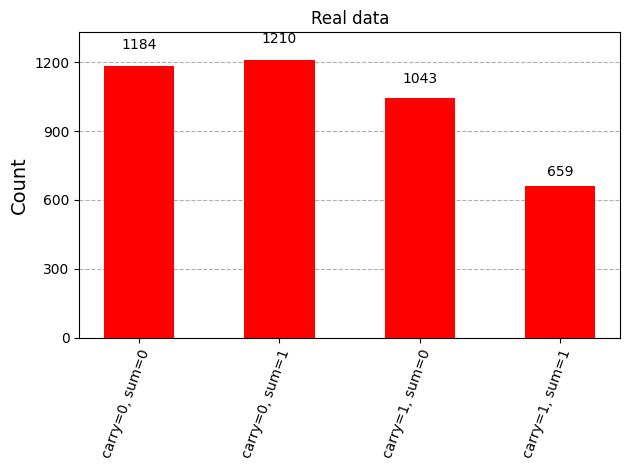

In [14]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = "ibm_kingston"
service = QiskitRuntimeService()
print(dir(service))
backend = service.backend(backend_name)

qc_transpiled = transpile(qc, backend=backend, optimization_level=0)
print("Transpiled and got the backend")

from qiskit_ibm_runtime import Sampler


sampler = Sampler(mode=backend)

job = sampler.run([qc_transpiled])

# # print(dir(job))

# print(f"job_id: {job.job_id()}\n")

result = job.result()
# print(result[0].data, "\n")
Real_counts = result[0].data.classicalRegister.get_counts()
real_pretty_counts = {
    "carry=0, sum=0": Real_counts.get("00", 0),
    "carry=0, sum=1": Real_counts.get("01", 0),
    "carry=1, sum=0": Real_counts.get("10", 0),
    "carry=1, sum=1": Real_counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}
RealHisto = plot_histogram(real_pretty_counts, title="Real data", color='red')
display(RealHisto)

# Calculate the error rate

In [15]:
addedWrongVals = Real_counts["01"] + Real_counts["10"] + Real_counts["11"]

error = round((addedWrongVals/4096) * 100,2)
print(f"Rate of faulty results: {error}%")

Rate of faulty results: 71.09%


## Compare both results

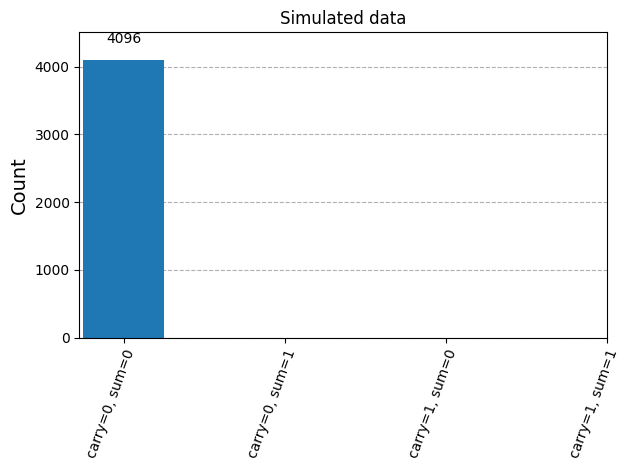

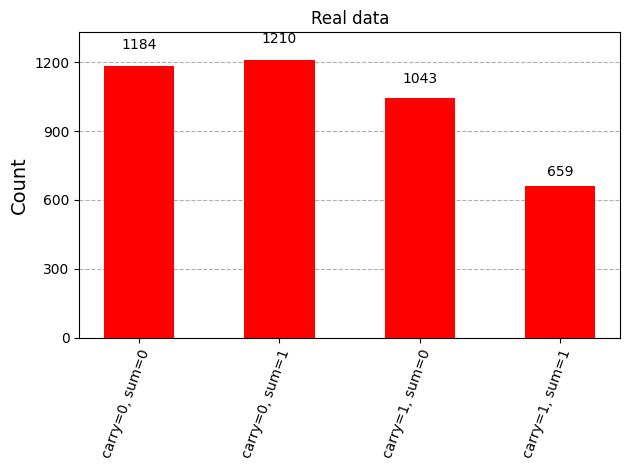

In [18]:
display(SimHisto, RealHisto)
# display(RealHisto)

# Backend metrics

## These can be extracted straight from the backend (they are hardware properties)

# Definitions: 

## T1 and T2

### T1 = energy relaxation time: Time a qubit stays excited before decaying into its ground state. (If the quantum circuit's execution lasts longer than T1, the probability that a qubit's amplitude reaches |0> increases)
### T2 = Dephasing time: Time a qubit retains its phasing information, which is needed For superposition and interference. (If the quantum circuit's execution lasts longer than T1, the probability that a qubit "loses" its phase information neeeded for superpostion)

### These both are important when the circuit's depth increases



## Prob_meas0_prep_1 and Prob_meas1_prep_0

### Prob_meas0_prep_1: The probability that, in a qubit, |1> was prepared, but |0> was meassured instead

### Prob_meas1_prep_0: The probaility that, in a qubit, |0> was prepared, but |1> was meassured instead

## Readout_error

### Proability that the measured bit is wrong (a combination of the two above)

In [ ]:
dic = (backend.properties().qubits[0][0].to_dict())
# print(dic)

for metric in backend.properties().qubits[0]:
    dic = metric.to_dict()

    print(f"Name of metric: {dic["name"]}")
    if(dic["unit"] != ""):
        print(f"Name of unit used for metric: {dic["unit"]}")
    print(f"Value of metric: {dic["value"]}\n")
    print("-"*40,"\n")


Name of metric: T1
Name of unit used for metric: us
Value of metric: 329.51336199962543

---------------------------------------- 

Name of metric: T2
Name of unit used for metric: us
Value of metric: 328.2727369436471

---------------------------------------- 

Name of metric: readout_error
Value of metric: 0.011962890625

---------------------------------------- 

Name of metric: prob_meas0_prep1
Value of metric: 0.02197265625

---------------------------------------- 

Name of metric: prob_meas1_prep0
Value of metric: 0.001953125

---------------------------------------- 

Name of metric: readout_length
Name of unit used for metric: ns
Value of metric: 2280

---------------------------------------- 



# Addition of 4 bit numbers using 4 full adders

Idea: Turn the above full adder into a function and use it to individually add the numbers via a loop (maybe), while sharing the same classical register

In [19]:
def FourBitQuantumAdder(number1 = None, number2 = None):

    from qiskit import QuantumCircuit
    # from qiskit.primitives import StatevectorSampler
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    sampler = StatevectorSampler()
    list_of_results = []

        
        #since these operations are from right to left, we iterate backwards:
        
    cr = ClassicalRegister(5,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    qr2 = QuantumRegister(1,"A1")
    qr3 = QuantumRegister(1,"A2")
    qr4 = QuantumRegister(1,"A3")
    qr5 = QuantumRegister(1,"A4")

    qr6 = QuantumRegister(1,"B1")
    qr7 = QuantumRegister(1,"B2")
    qr8 = QuantumRegister(1,"B3")
    qr9 = QuantumRegister(1,"B4")
    qr10 = QuantumRegister(1,"Carry1")
    qr11 = QuantumRegister(1,"Carry2")
    qr12 = QuantumRegister(1,"Carry3")
    qr13 = QuantumRegister(1,"Carry4")
    qr14 = QuantumRegister(1,"Carry5")
    qr15 = QuantumRegister(1,"Sum1")
    qr16 = QuantumRegister(1,"Sum2")
    qr17 = QuantumRegister(1,"Sum3")
    qr18 = QuantumRegister(1,"Sum4")
    qr19 = QuantumRegister(1,"Temp1")
    qr20 = QuantumRegister(1,"Temp2")
    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, qr12, qr13, qr14, qr15, qr16, qr17, qr18, qr19, qr20, cr, name='Full-adder circuit')

    control_1 = 0
    control_2 = 1
    A1 = 2
    A2 = 3
    A3 = 4
    A4 = 5
    B1 = 6
    B2 = 7
    B3 = 8
    B4 = 9
    Carry1 = 10
    Carry2 = 11
    Carry3 = 12
    Carry4 = 13
    Carry5 = 14
    Sum1 = 15
    Sum2 = 16
    Sum3 = 17
    Sum4 = 18
    Temp1 = 19
    Temp2 = 20

    if(number1 != None and number2 != None):
        if((number1 < 0 or number1 > 15 or number2 < 0 or number2 > 15)):
            print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
            return False
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        count = 2
        if(len(binary1) != 4):
            length = 4 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 4):
            length = 4 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        # print(f"first operand {binary1} and second operand {binary2}\n")


    
    #read the input and set the 
    #appropiate qbits to |1>

        for x in range(0,4):
            if(binary1[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1
    else:
        count = 2
        for x in range(0,4):
            qc.append(HGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            qc.append(HGate(), [count])
            count += 1





    #set the control bit to |1>
    qc.append(XGate(), [control_1])
    qc.append(XGate(), [control_2])

    #set up the SUM of the LSBs (least signigicant bits)
    #First XOR (sum):
    #XOR A4 and B4 to fill T1
    qc.append(CCXGate(), [control_2,A4,Temp1])
    qc.append(CCXGate(), [control_2,B4,Temp1])

    #Perform XOR between the T1 and the carry to get the sum
        #Xor with T1
    qc.append(CCXGate(), [control_2,Temp1,Sum1])

        #Xor with carry ****
    qc.append(CCXGate(), [control_2,Carry1,Sum1])

    #Sum between A4 and B4 is done



    #Carry for A4 and B4
        #AND between T1 and C-IN dumped into T2 ****
    qc.append(CCXGate(),[Carry1,Temp1,Temp2])


        #now we clean T1 from the A4 XOR B4 operation
    qc.append(CCXGate(), [control_2,B4,Temp1])
    qc.append(CCXGate(), [control_2,A4,Temp1])

        #AND between A4 and B4 into T1
    qc.append(CCXGate(),[A4,B4,Temp1])

    #OR T1 and T2:
        #First, Not(T2)
    qc.append(CCXGate(), [control_1,control_2,Temp2])
        #Second, Not(T1)
    qc.append(CCXGate(), [control_1, control_2, Temp1])
    #And both T1 and T2 into carry bit 2 
    qc.append(CCXGate(), [Temp1, Temp2, Carry2])
    #Finally, invert carry bit
    qc.append(CCXGate(), [control_1, control_2, Carry2])

    #Or finished and Carry computed, clean T1 and T2
    # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

    #reverse the NOT and AND
        #the NOT
    qc.append(CCXGate(), [control_1, control_2, Temp1])

        #the and
    qc.append(CCXGate(), [A4, B4, Temp1])

    #T1 should be back into its OG state, so now we recompute A XOR B
    qc.append(CCXGate(), [control_2,A4,Temp1])
    qc.append(CCXGate(), [control_2,B4,Temp1])

    #undo NOT T2
    qc.append(CCXGate(), [control_1,control_2,Temp2])

    #UNDO T1 AND C_In
    qc.append(CCXGate(),[Carry1,Temp1,Temp2])

    #T2 is now back to its og state, now clean T1 again
    qc.append(CCXGate(), [control_2,B4,Temp1])
    qc.append(CCXGate(), [control_2,A4,Temp1])

    #Both T1 and T2 should be |0> again. Lets check

    # #T1 unto classicalReg[0]
    # qc.measure(Temp1,0)
    # #T2 unto classicalReg[1]
    # qc.measure(Temp2,1)

    # result = sampler.run([qc], shots=(30 * 1024)).result()
    # print(result[0].data, "\n")
    # counts = result[0].data.classicalRegister.get_counts()
    # display(plot_histogram(counts))

    #Check complete, it works

    # Now we are done
    # qc.append(XGate(), [12])

    #Swap the result in Sum into B4 and reset Sum
        #Swap SUM and B4
    # qc.swap(Sum, B4)
        #Reset SUM
    # qc.append(Reset(), [11])
    

    #Now repeat for all qbits


#--------------A3 and B3--------------------------
    #set up the SUM of the LSBs (least signigicant bits)
    #First XOR (sum):
    #XOR A and B to fill T1
    qc.append(CCXGate(), [control_2,A3,Temp1])
    qc.append(CCXGate(), [control_2,B3,Temp1])

    #Perform XOR between the T1 and the carry to get the sum
        #Xor with T1
    qc.append(CCXGate(), [control_2,Temp1,Sum2])

        #Xor with carry ****
    qc.append(CCXGate(), [control_2,Carry2,Sum2])

    #Sum between A4 and B4 is done



    #Carry for A4 and B4
        #AND between T1 and C-IN dumped into T2 ****
    qc.append(CCXGate(),[Carry2,Temp1,Temp2])


        #now we clean T1 from the A XOR B operation
    qc.append(CCXGate(), [control_2,B3,Temp1])
    qc.append(CCXGate(), [control_2,A3,Temp1])

        #AND between A and B into T1
    qc.append(CCXGate(),[A3,B3,Temp1])

    #OR T1 and T2:
        #First, Not(T2)
    qc.append(CCXGate(), [control_1,control_2,Temp2])
        #Second, Not(T1)
    qc.append(CCXGate(), [control_1, control_2, Temp1])
    #And both T1 and T2 into carry bit 3 
    qc.append(CCXGate(), [Temp1, Temp2, Carry3])
    #Finally, invert carry bit
    qc.append(CCXGate(), [control_1, control_2, Carry3])

    #Or finished and Carry computed, clean T1 and T2
    # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

    #reverse the NOT and AND
        #the NOT
    qc.append(CCXGate(), [control_1, control_2, Temp1])

        #the and
    qc.append(CCXGate(), [A3, B3, Temp1])

    #T1 should be back into its OG state, so now we recompute A XOR B
    qc.append(CCXGate(), [control_2,A3,Temp1])
    qc.append(CCXGate(), [control_2,B3,Temp1])

    #undo NOT T2
    qc.append(CCXGate(), [control_1,control_2,Temp2])

    #UNDO T1 AND C_In
    qc.append(CCXGate(),[Carry2,Temp1,Temp2])

    #T2 is now back to its og state, now clean T1 again
    qc.append(CCXGate(), [control_2,B3,Temp1])
    qc.append(CCXGate(), [control_2,A3,Temp1])
#-------------------------------------------

#--------------A2 and B2--------------------------
    #set up the SUM of the LSBs (least signigicant bits)
    #First XOR (sum):
    #XOR A and B to fill T1
    qc.append(CCXGate(), [control_2,A2,Temp1])
    qc.append(CCXGate(), [control_2,B2,Temp1])

    #Perform XOR between the T1 and the carry to get the sum
        #Xor with T1
    qc.append(CCXGate(), [control_2,Temp1,Sum3])

        #Xor with carry ****
    qc.append(CCXGate(), [control_2,Carry3,Sum3])

    #Sum between A4 and B4 is done



    #Carry for A4 and B4
        #AND between T1 and C-IN dumped into T2 ****
    qc.append(CCXGate(),[Carry3,Temp1,Temp2])


        #now we clean T1 from the A XOR B operation
    qc.append(CCXGate(), [control_2,B2,Temp1])
    qc.append(CCXGate(), [control_2,A2,Temp1])

        #AND between A and B into T1
    qc.append(CCXGate(),[A2,B2,Temp1])

    #OR T1 and T2:
        #First, Not(T2)
    qc.append(CCXGate(), [control_1,control_2,Temp2])
        #Second, Not(T1)
    qc.append(CCXGate(), [control_1, control_2, Temp1])
    #And both T1 and T2 into carry bit 4
    qc.append(CCXGate(), [Temp1, Temp2, Carry4])
    #Finally, invert carry bit
    qc.append(CCXGate(), [control_1, control_2, Carry4])

    #Or finished and Carry computed, clean T1 and T2
    # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

    #reverse the NOT and AND
        #the NOT
    qc.append(CCXGate(), [control_1, control_2, Temp1])

        #the and
    qc.append(CCXGate(), [A2, B2, Temp1])

    #T1 should be back into its OG state, so now we recompute A XOR B
    qc.append(CCXGate(), [control_2,A2,Temp1])
    qc.append(CCXGate(), [control_2,B2,Temp1])

    #undo NOT T2
    qc.append(CCXGate(), [control_1,control_2,Temp2])

    #UNDO T1 AND C_In
    qc.append(CCXGate(),[Carry3,Temp1,Temp2])

    #T2 is now back to its og state, now clean T1 again
    qc.append(CCXGate(), [control_2,B2,Temp1])
    qc.append(CCXGate(), [control_2,A2,Temp1])
#-------------------------------------------

#--------------A1 and B1--------------------------
    #set up the SUM of the LSBs (least signigicant bits)
    #First XOR (sum):
    #XOR A and B to fill T1
    qc.append(CCXGate(), [control_2,A1,Temp1])
    qc.append(CCXGate(), [control_2,B1,Temp1])

    #Perform XOR between the T1 and the carry to get the sum
        #Xor with T1
    qc.append(CCXGate(), [control_2,Temp1,Sum4])

        #Xor with carry ****
    qc.append(CCXGate(), [control_2,Carry4,Sum4])

    #Sum between A1 and B1 is done

    #Carry for A1 and B1
        #AND between T1 and C-IN dumped into T2 ****
    qc.append(CCXGate(),[Carry4,Temp1,Temp2])


        #now we clean T1 from the A XOR B operation
    qc.append(CCXGate(), [control_2,B1,Temp1])
    qc.append(CCXGate(), [control_2,A1,Temp1])

        #AND between A and B into T1
    qc.append(CCXGate(),[A1,B1,Temp1])

    #OR T1 and T2:
        #First, Not(T2)
    qc.append(CCXGate(), [control_1,control_2,Temp2])
        #Second, Not(T1)
    qc.append(CCXGate(), [control_1, control_2, Temp1])
    #And both T1 and T2 into carry bit 4
    qc.append(CCXGate(), [Temp1, Temp2, Carry5])
    #Finally, invert carry bit
    qc.append(CCXGate(), [control_1, control_2, Carry5])

    #Or finished and Carry computed, clean T1 and T2
    # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

    #reverse the NOT and AND
        #the NOT
    qc.append(CCXGate(), [control_1, control_2, Temp1])

        #the and
    qc.append(CCXGate(), [A1, B1, Temp1])

    #T1 should be back into its OG state, so now we recompute A XOR B
    qc.append(CCXGate(), [control_2,A1,Temp1])
    qc.append(CCXGate(), [control_2,B1,Temp1])

    #undo NOT T2
    qc.append(CCXGate(), [control_1,control_2,Temp2])

    #UNDO T1 AND C_In
    qc.append(CCXGate(),[Carry4,Temp1,Temp2])

    #T2 is now back to its og state, now clean T1 again
    qc.append(CCXGate(), [control_2,B1,Temp1])
    qc.append(CCXGate(), [control_2,A1,Temp1])
#-------------------------------------------


    # #now we can meassure carry and Sum
    #carry
    qc.measure(Carry5,4)
    #and sum
    qc.measure(Sum4, 3)
    qc.measure(Sum3, 2)
    qc.measure(Sum2, 1)
    qc.measure(Sum1, 0)
    

    # display(qc.draw("mpl"))
    # samplerSim = StatevectorSampler()
    # result = samplerSim.run([qc], shots=(1024*4)).result()
    # counts = result[0].data.classicalRegister.get_counts()
    # pretty_counts = {}
    # for bitstring, count in counts.items():
    #     carry = bitstring[0]
    #     sum_bits = bitstring[1:]

    #     label = f"carry={carry}, sum={sum_bits}"
    #     pretty_counts[label] = count

    #     print(bitstring, "→",
    #         "carry =",     bitstring[0],
    #         "sum bits =", bitstring[1:],
    #         "Result =", int(bitstring, 2))

    # display(plot_histogram(pretty_counts))



    # lKeys = list(counts.keys())
    # lKeys.sort()
    # print(lKeys)
        # if(keys[0][0] == 1):
        #     carryOut = 1
        # else:
        #     carryOut = 0
        # print(f"\n i {list_of_results}")
    return qc

# for numbers in range(31):
#     test = numbers + numbers
#     if(test == FourBitQuantumAdder(numbers,numbers)):
#         print(f"failed test for {numbers}")
# FourBitQAdder = FourBitQuantumAdder(0, 15)

FourBitQAdder = FourBitQuantumAdder(9, 10)



In [ ]:
#Test all possibilities, don't re-run this

for i in range(16):
    for j in range(16):
        print(f"Checkig that {i} + {j} = {i + j}")
        FourBitQuantumAdder(i,j)
        print("\n")
        

Checkig that 0 + 0 = 0
00000 → carry = 0 sum bits = 0000 Result = 0


Checkig that 0 + 1 = 1
00001 → carry = 0 sum bits = 0001 Result = 1


Checkig that 0 + 2 = 2
00010 → carry = 0 sum bits = 0010 Result = 2


Checkig that 0 + 3 = 3
00011 → carry = 0 sum bits = 0011 Result = 3


Checkig that 0 + 4 = 4
00100 → carry = 0 sum bits = 0100 Result = 4


Checkig that 0 + 5 = 5
00101 → carry = 0 sum bits = 0101 Result = 5


Checkig that 0 + 6 = 6
00110 → carry = 0 sum bits = 0110 Result = 6


Checkig that 0 + 7 = 7
00111 → carry = 0 sum bits = 0111 Result = 7


Checkig that 0 + 8 = 8
01000 → carry = 0 sum bits = 1000 Result = 8


Checkig that 0 + 9 = 9
01001 → carry = 0 sum bits = 1001 Result = 9


Checkig that 0 + 10 = 10
01010 → carry = 0 sum bits = 1010 Result = 10


Checkig that 0 + 11 = 11
01011 → carry = 0 sum bits = 1011 Result = 11


Checkig that 0 + 12 = 12
01100 → carry = 0 sum bits = 1100 Result = 12


Checkig that 0 + 13 = 13
01101 → carry = 0 sum bits = 1101 Result = 13


Checkig 

Quantum circuit (QC) being evaluated:  


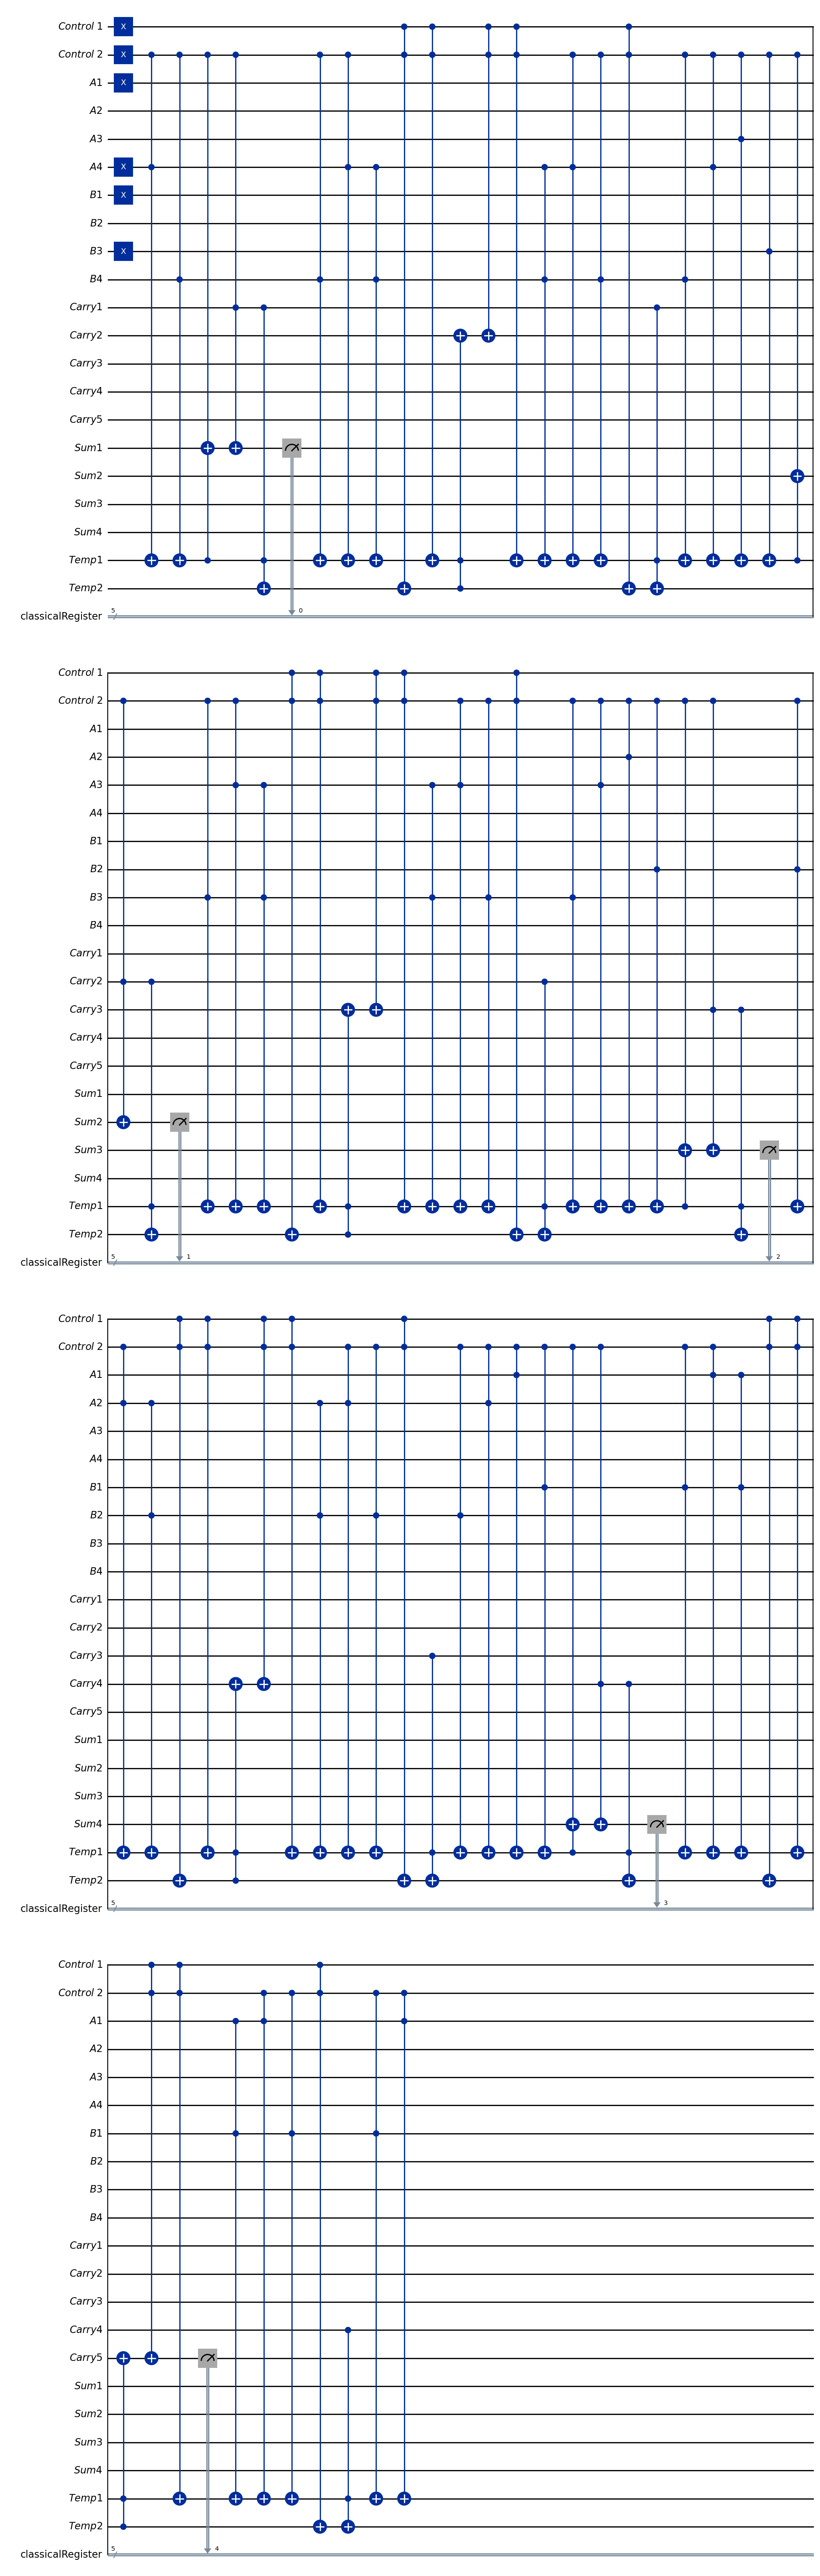

Transpiled qc and got the backend
job_id: d81po47oha1c73bknar0
Job metrics: {'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.45.0,qiskit-2.3.0*,qiskit_aer-0.17.2', 'timestamps': {'created': '2026-05-12T21:30:56.849389Z', 'finished': '2026-05-12T21:31:10.647219Z', 'running': '2026-05-12T21:30:58.158385Z'}, 'bss': {'seconds': 3}, 'usage': {'quantum_seconds': 3, 'seconds': 3, 'status': 'complete'}}

Job duration {'quantum_seconds': 3, 'seconds': 3, 'status': 'complete'}


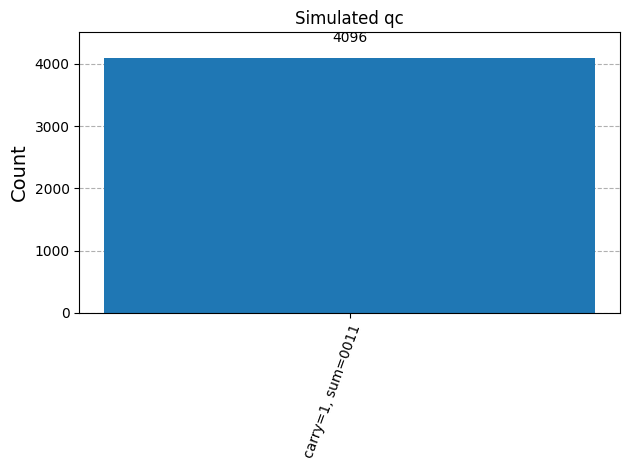

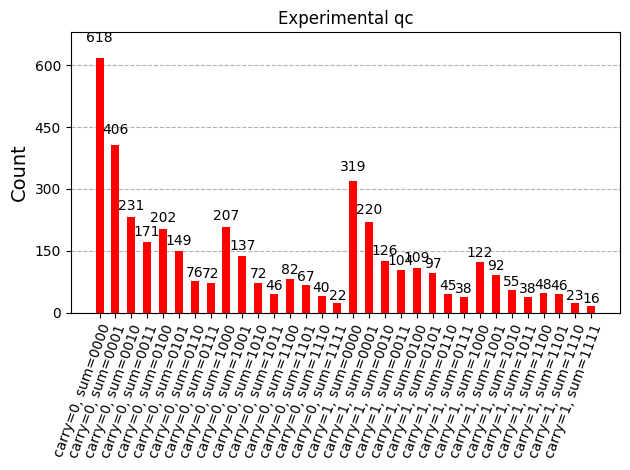

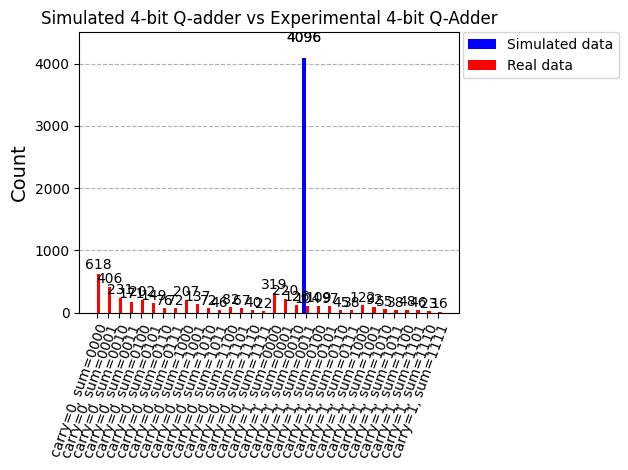




Simualted quantum ciruit depth vs transpiled quantum circuit's depth
og circuit's depth: 77
transpiled circuit's depth: 4927

Meassuring quantum circuit's T-depth
T-depth: 384
Hardware metrics

Name of metric: T1
Name of unit used for metric: us
Value of metric: 329.51336199962543

---------------------------------------- 

Name of metric: T2
Name of unit used for metric: us
Value of metric: 328.2727369436471

---------------------------------------- 

Name of metric: readout_error
Value of metric: 0.0228271484375

---------------------------------------- 

Name of metric: prob_meas0_prep1
Value of metric: 0.044189453125

---------------------------------------- 

Name of metric: prob_meas1_prep0
Value of metric: 0.00146484375

---------------------------------------- 

Name of metric: readout_length
Name of unit used for metric: ns
Value of metric: 2280

---------------------------------------- 



In [22]:
from Quantum_Circuit_Tests_and_metrics import runQCTests_and_metrics
runQCTests_and_metrics(FourBitQAdder, "Simulated 4-bit Q-adder vs Experimental 4-bit Q-Adder")